# Head Count Ablation 

## Introduction

Building on the probe into exploring the redundancy contained in the output attention matrix $W^O$ as model size increases for GPT2 models, I wished to further explore this phenomenon, by exploring a potential cause of this redundancy. In particular, in the probe it was identified that as model size increased the level of redundancy contained in the model increased and thus the level of compression applicable to the model also increased. What was not possible to establish was the exact cause of this increase, whether it was the number of model parameters, the number of layers, the number of attention heads, or a combination. 

What I would like to explore in this notebook is whether, holding hidden size, layers and parameter count fixed while varying the number of attention heads changes the level of redundancy contained in the model and thus the level of compression that can be applied. For this experiment, I will take the GPT2 reduced scale model with a hidden size of 768, 6 layers, a feed-forward inner size of 3072 and a context length of 512. I will vary the number of attention heads per layer from [4, 8, 16, 32] and I will also apply different levels of compression [384, 192, 96, 48]. For each pair of output compression dimension and number of heads an experiment will be conducted pretraining the GPT2 model from scratch. Each model, approx. 80m parameters, will be trained for a total of 4000 steps on 262m OpenWebText tokens. Baseline models will also be trained for each of the n_head dimensions, with no compression applied to $W^O$.

Within each set of experiments (grouped by number of attention heads), I would expect the level of perplexity to increase with increased level of compression. While across the different attention head experiments, I expect that the level of increase in perplexity would reduce for models with more attention heads, i.e. more heads equals more redundancy, thus more redundancy to remove. This would positively signal that scaling the number of attention heads would likely increase the level of redundancy in $W^O$.

The results of this ablation study will be explored in this notebook. 

## Define the necessary libraries

In [3]:
import math
import pandas as pd
import wandb
import re
import matplotlib.pyplot as plt
from matplotlib.ticker import NullLocator

In [4]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## Import the CSV results

In [5]:
# Define the data path
data_path = "data/ablation_results.csv"

In [6]:
# Review the data
df = pd.read_csv(data_path)
df.head()
df.tail()
df.shape

,n_head,attention_mechanism,d_model,output_compression_dim,r,ppl,ppl_norm,pretraining_cka,pretraining_next_token_accuracy,n_params,GFLOPS,max_steps
0,4,MHA,768,768.0,1.0000,52.7398,1.000000,0.5684,0.3310,81519360,664.287,4000
1,4,MHAE,768,384.0,0.5000,60.4110,1.145454,0.5225,0.3203,81526272,664.334,4000
2,4,MHAE,768,192.0,0.2500,58.1421,1.102433,0.4894,0.3237,79753344,649.815,4000
3,4,MHAE,768,96.0,0.1250,54.6716,1.036629,0.5030,0.3285,78866880,642.555,4000
4,4,MHAE,768,48.0,0.0625,55.8650,1.059257,0.4765,0.3261,78423648,638.925,4000


,n_head,attention_mechanism,d_model,output_compression_dim,r,ppl,ppl_norm,pretraining_cka,pretraining_next_token_accuracy,n_params,GFLOPS,max_steps
15,32,MHA,768,768.0,1.0000,53.4870,1.000000,0.3329,0.3278,81519360,664.287,4000
16,32,MHAE,768,384.0,0.5000,59.6050,1.114383,0.3004,0.3193,81526272,664.334,4000
17,32,MHAE,768,192.0,0.2500,60.4581,1.130333,0.3460,0.3181,79753344,649.815,4000
18,32,MHAE,768,96.0,0.1250,56.2099,1.050908,0.3426,0.3232,78866880,642.555,4000
19,32,MHAE,768,48.0,0.0625,54.8455,1.025399,0.3315,0.3269,78423648,638.925,4000


(20, 12)

## Explore the data in more detail

In [7]:
print("MHAE perplexity (n_head x d_o)\n")
print(df.pivot(index="n_head", columns="output_compression_dim", values="ppl").round(2))

MHAE perplexity (n_head x d_o)

output_compression_dim  48.0   96.0   192.0  384.0  768.0
n_head                                                   
4                       55.86  54.67  58.14  60.41  52.74
8                       55.12  54.11  60.12  59.68  52.03
16                      54.57  54.17  59.73  59.82  53.00
32                      54.85  56.21  60.46  59.60  53.49


In [8]:
print("MHAE / MHA\n")
print(df.pivot(index="n_head", columns="output_compression_dim", values="ppl_norm").round(3))

MHAE / MHA

output_compression_dim  48.0   96.0   192.0  384.0  768.0
n_head                                                   
4                       1.059  1.037  1.102  1.145    1.0
8                       1.059  1.040  1.156  1.147    1.0
16                      1.030  1.022  1.127  1.129    1.0
32                      1.025  1.051  1.130  1.114    1.0


In [9]:
# Examine the percentage gap between the MHA and MHAE with largest level of compression
hardest = df["output_compression_dim"].min()
gap = df[df.output_compression_dim == hardest].set_index("n_head")["ppl_norm"].sub(1).mul(100).round(1)
gap

n_head
4     5.9
8     5.9
16    3.0
32    2.5
Name: ppl_norm, dtype: float64

From the above tables one can see that:

1. As the number of heads increases for the baselines the perplexity increases (except for n_head=4).
2. It appears as if at lower levels of compression higher perplexity is obtained. And conversly, higher levels of compression return lower levels of perplexity which is counter intutative to what I would have expected. And would potientially indicate that something is wrong with my experiment.
3. For the highest level of compression, as the number of heads increases the perplexity approaches that of the baseline model.
4. The issue with these results is that there is no clear pattern as the results dont tend to be monotonic.

Lets explore the plotting results.

## Plot the results

In [67]:
def plots(df, save="data/ablation_analysis.png"):
    """
    Plot the perplexity curves.
    """
    head_counts = sorted(df["n_head"].unique())
    output_compression_dim_vals = sorted(df["output_compression_dim"].unique(), reverse=True)
    hcol = dict(zip(head_counts, plt.cm.viridis([i / max(len(head_counts)-1, 1) for i in range(len(head_counts))])))
    ocol = dict(zip(
        output_compression_dim_vals, 
        plt.cm.plasma([i / max(len(output_compression_dim_vals)-1, 1) for i in range(len(output_compression_dim_vals))])
    ))

    fig, axes = plt.subplots(4, 1, figsize=(10, 12))
    ax_a, ax_b, ax_c, ax_d = axes.flat

    # MHAE/MHA vs compression
    for h in head_counts:
        d = df[(df.n_head == h) & (df.r != 1)].sort_values("r")
        ax_a.plot(d["r"], d["ppl"], "-o", color=hcol[h], label=f"{h} heads")
    ax_a.set_title("MHAE / MHA vs compression")
    ax_a.set_ylabel("ppl / dense-MHA (same n_head)")
    ax_a.set_xlabel("compression")

    r_vals = sorted(df["r"].unique(), reverse=True)
    r_vals = r_vals[1:]
    ax_a.set_xscale("log", base=2)
    ax_a.grid(True, alpha=0.8)
    ax_a.set_xticks(r_vals)
    ax_a.set_xticklabels([f"{r:g}" for r in r_vals])
    ax_a.xaxis.set_minor_locator(NullLocator())
    ax_a.invert_xaxis()
    ax_a.legend(title="heads")
    
    # MHAE/MHA vs compression normed
    for h in head_counts:
        d = df[(df.n_head == h) & (df.r != 1)].sort_values("r")
        ax_b.plot(d["r"], d["ppl_norm"], "-o", color=hcol[h], label=f"{h} heads")
    ax_b.axhline(1.0, color="grey", lw=0.8, ls=":")
    ax_b.set_title("MHAE / MHA vs compression")
    ax_b.set_ylabel("ppl")
    ax_b.set_xlabel("compression")

    r_vals = sorted(df["r"].unique(), reverse=True)
    r_vals = r_vals[1:]
    ax_b.set_xscale("log", base=2)
    ax_b.grid(True, alpha=0.3)
    ax_b.set_xticks(r_vals)
    ax_b.set_xticklabels([f"{r:g}" for r in r_vals])
    ax_b.xaxis.set_minor_locator(NullLocator())
    ax_b.invert_xaxis()
    ax_b.legend(title="heads")

    # gap vs head count
    for o in output_compression_dim_vals:
        d = df[(df.output_compression_dim == o) & (df.r != 1)].sort_values("n_head")
        ax_c.plot(d["n_head"], d["ppl"], "-o", color=ocol[o], label=f"d_o={o}")
    ax_c.set_xscale("log", base=2)
    ax_c.set_xticks(head_counts)
    ax_c.set_xticklabels(head_counts)
    ax_c.xaxis.set_minor_locator(NullLocator())
    ax_c.set_title("MHA -> MHAE gap vs head count")
    ax_c.set_xlabel("n_head")
    ax_c.set_ylabel("ppl")
    ax_c.grid(True, alpha=0.7)
    ax_c.legend(title="compression")

    # gap vs head count
    for o in output_compression_dim_vals:
        d = df[(df.output_compression_dim == o) & (df.r != 1)].sort_values("n_head")
        ax_d.plot(d["n_head"], d["ppl_norm"], "-o", color=ocol[o], label=f"d_o={o}")
    ax_d.axhline(1.0, color="grey", lw=0.7, ls=":")
    ax_d.set_xscale("log", base=2)
    ax_d.set_xticks(head_counts)
    ax_d.set_xticklabels(head_counts)
    ax_d.xaxis.set_minor_locator(NullLocator())
    ax_d.set_title("MHA -> MHAE gap vs head count")
    ax_d.set_xlabel("n_head")
    ax_d.set_ylabel("ppl / dense-MHA")
    ax_d.grid(True, alpha=0.3)
    ax_d.legend(title="compression")

    fig.suptitle("Head-count ablation: does W$^O$ compressibility grow with heads?", fontsize=14, y=1.01)
    fig.tight_layout()
    fig.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()

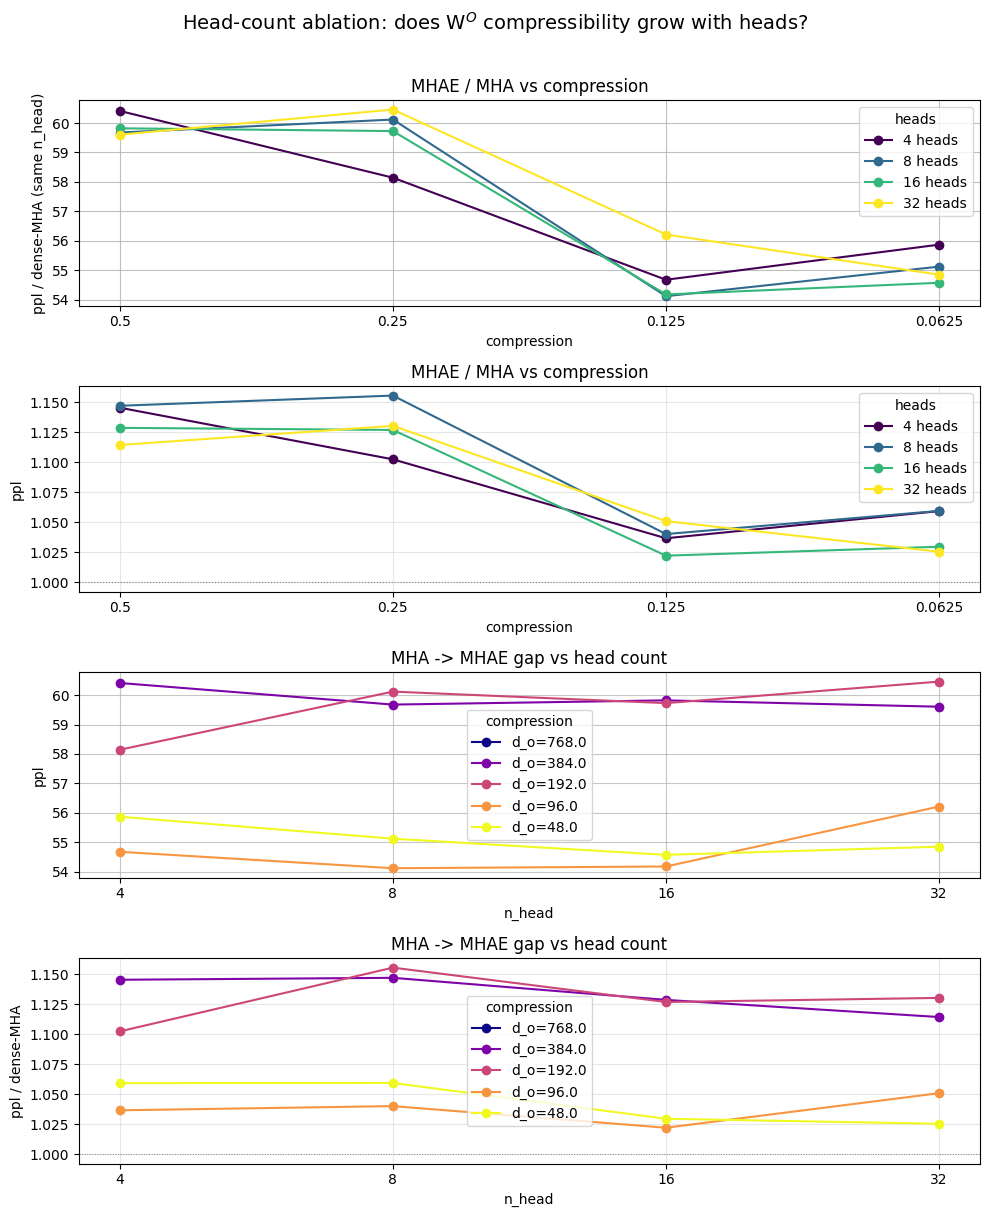

In [68]:
# Explore the results
plots(df)

## Conclusion

1. Examining the first plot, we can see that the perplexity is in general decreasing as the level of compression increases, which is somewhat counter intutative. As usually as the level of compression increases the perplexity increases.
2. The same pattern is seen in plot 2, where the perplexity scores have been normalised.
3. Finally, in the the last two plots, the general trend appears that as the number of heads increaes the level of perplexity remains fairly constant or decreases slightly.

Overall this notebook does not support my initial hypothesis and the results are a bit strange, I believe I may have undertrained the models here? This will need to be further investigated!